In [12]:
import numpy as np

from efsprapy.mcs1.calcs import calculate_ignition_time_ftp

t = np.arange(0, 60 * 60 * 5, 0.5)

list_t_ig = list()
list_q_inc = list()
for q_inc in range(1000, 20000, 10):
    try:
        t_ig, ftp = calculate_ignition_time_ftp(
            t=t, q_inc=np.full_like(t, q_inc), ftp_chf=7.7e3, ftp_index=1.7, ftp_target=20423,
        )
    except:
        continue
    list_t_ig.append(t_ig)
    list_q_inc.append(q_inc)


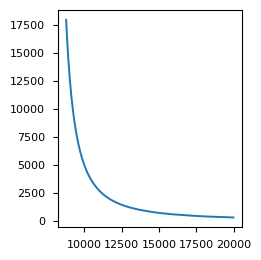

In [13]:
%matplotlib inline
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-paper')

fig, ax = plt.subplots(figsize=(2.7, 2.7), dpi=100)

ax.plot(list_q_inc, list_t_ig)

fig.tight_layout()

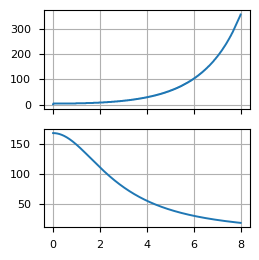

In [14]:
from fsetools.lib.fse_thermal_radiation import phi_parallel_any_br187

t = np.arange(0, 60 * 60 * 10, 1)
list_2_sep = [0]
list_2_t_ig = [1]
list_2_phi = [1]
list_2_q_inc = [168]
for sep in np.concatenate((np.arange(0, 8, 0.01)[1:],)):
    try:
        phi = phi_parallel_any_br187(5, 5, 2.5, 2.5, sep)
        q_inc = 168e3 * phi
        t_ig, ftp = calculate_ignition_time_ftp(
            t=t, q_inc=np.full_like(t, q_inc),
            ftp_chf=7.7e3, ftp_index=1.7, ftp_target=20423,
        )
    except:
        continue
    list_2_sep.append(sep)
    list_2_t_ig.append(t_ig)
    list_2_phi.append(phi)
    list_2_q_inc.append(q_inc * 1e-3)

fig, (ax1, ax2) = plt.subplots(figsize=(2.7, 2.7 * 2 * 0.5), nrows=2, dpi=100, sharex=True)
ax1.plot(list_2_sep, list_2_t_ig)
ax2.plot(list_2_sep, list_2_q_inc)
# ax1.set_xscale('log')
# ax1.set_xlim(0, 3000)
# ax1.set_yscale('log')
ax1.grid()
ax2.grid()
fig.tight_layout()